# 54 — Secondary English eval slice (soft rebalance)

This notebook is **not** the canonical English benchmark. It **consumes** the aligned English artifacts produced by **`32_english_dataset_alignment.ipynb`** (`df_final.parquet` or `train`/`val`/`test` under `data/processed/english_dataset_v1/`) and builds a **more evaluation-friendly** CSV with **reduced—but not eliminated—class imbalance**.

**Principles**

- **Original mapped data are never rewritten**; only a new eval slice CSV is emitted.
- **Semantic honesty:** same `supercategory` labels as in 32; no synthetic `sales_account`.
- **Imperfect balance:** targets are **median-relative** with `SOFT_PULL`; heavy classes are downsampled, minorities keep all deduped rows—distribution stays **realistic**, not 1:1.

**Outputs:** `notebooks/results/english_balanced_eval/` · `figures/english_balanced_eval/`

**When to use 54 vs 32:** use **32** for benchmark definition, coverage, and official splits; use **54** when you want a **softer** class mix for reporting or model comparison without the raw extreme skew of the full map.



In [4]:
import json
import re
import shutil
import zlib
from pathlib import Path
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_CWD = Path.cwd()
NOTEBOOK_DIR = _CWD if _CWD.name == "notebooks" else (_CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
PROCESSED_EN = REPO_ROOT / "data" / "processed" / "english_dataset_v1"
RESULTS_DIR = NOTEBOOK_DIR / "results" / "english_balanced_eval"
FIG_DIR = REPO_ROOT / "figures" / "english_balanced_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ALIGN_RESULT_ROOT = REPO_ROOT / "notebooks" / "results" / "english_dataset_alignment"
CANONICAL_ALIGN_NOTEBOOK = "notebooks/32_english_dataset_alignment.ipynb"
ALIGN_MANIFEST_PATH = ALIGN_RESULT_ROOT / "32_english_benchmark_manifest.json"

RANDOM_SEED = 42
# For classes *above* median deduped size: target = median + SOFT_PULL * (n - median)
SOFT_PULL = 0.38
SALES_ACCOUNT = "sales_account"
EVAL_SLICE_NAME = "english_soft_rebalanced_8class_eval"
PRIMARY_CSV = RESULTS_DIR / "english_balanced_8class_eval.csv"
ARCHIVE_HARD_90 = RESULTS_DIR / "english_eval_hard_90cap_archive.csv"

EIGHT_CLASS_ORDER = [
    "backend_general_dev",
    "generic_it_ops",
    "it_governance_leadership",
    "project_product",
    "sysadmin_devops_network",
    "tech_support_helpdesk",
    "technical_specialized",
    "web_frontend",
]


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text).strip().lower())


def load_full_english(processed_dir: Path) -> pd.DataFrame:
    pq = processed_dir / "df_final.parquet"
    if pq.exists():
        return pd.read_parquet(pq)
    parts = []
    for sp in ("train", "val", "test"):
        fp = processed_dir / f"{sp}.csv"
        if not fp.exists():
            continue
        chunk = pd.read_csv(fp)
        chunk["split"] = sp
        parts.append(chunk)
    if not parts:
        raise FileNotFoundError(
            f"No df_final.parquet or train/val/test CSV under {processed_dir}."
        )
    return pd.concat(parts, ignore_index=True)


def class_seed(base: int, class_name: str) -> int:
    h = zlib.adler32(class_name.encode("utf-8")) & 0xFFFFFFFF
    return int((base + h) % (2**31 - 1))


def dedupe_normalized(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["_norm_text"] = out["resume_text"].map(normalize_text)
    return out.drop_duplicates(subset=["_norm_text"], keep="first")


def allocate_stratum_targets(sizes: np.ndarray, n: int) -> np.ndarray:
    sizes = np.asarray(sizes, dtype=int)
    if sizes.sum() == 0:
        return np.zeros_like(sizes)
    prop = sizes.astype(float) / sizes.sum() * n
    tgt = np.floor(prop).astype(int)
    tgt = np.minimum(tgt, sizes)
    r = n - int(tgt.sum())
    remainder = prop - tgt
    order = list(np.argsort(-remainder))
    guard = 0
    while r > 0 and guard < n * 20:
        moved = False
        for idx in order:
            if r == 0:
                break
            if tgt[idx] < sizes[idx]:
                tgt[idx] += 1
                r -= 1
                moved = True
        if not moved:
            break
        guard += 1
    return tgt


def stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy().drop(columns=["_norm_text"], errors="ignore")
    work = df.copy().reset_index(drop=True)
    work["_rid"] = np.arange(len(work), dtype=int)
    work["_stratum"] = (
        work["source"].astype(str).str.slice(0, 80)
        + "||"
        + work["has_city_mention"].map(lambda x: str(bool(x)))
    )
    vc = work["_stratum"].value_counts()
    strata = vc.index.tolist()
    sizes = vc.reindex(strata).values.astype(int)
    targets = allocate_stratum_targets(sizes, n)
    rng = np.random.default_rng(seed)
    picked_rids = []
    for sname, k in zip(strata, targets):
        if k <= 0:
            continue
        sub = work.loc[work["_stratum"] == sname]
        take = min(k, len(sub))
        sm = sub.sample(n=take, random_state=int(rng.integers(0, 2**31 - 1)), replace=False)
        picked_rids.extend(sm["_rid"].tolist())
    out = work.loc[work["_rid"].isin(picked_rids)].copy()
    if len(out) < n:
        rem = work.loc[~work["_rid"].isin(picked_rids)]
        need = n - len(out)
        if len(rem) > 0 and need > 0:
            extra = rem.sample(n=min(need, len(rem)), random_state=seed + 999, replace=False)
            out = pd.concat([out, extra], ignore_index=True)
    if len(out) > n:
        out = out.sample(n=n, random_state=seed + 1000, replace=False)
    return out.drop(columns=["_stratum", "_rid"], errors="ignore")


def soft_class_targets(dedup_counts: Dict[str, int]) -> Tuple[dict, float]:
    vals = {c: int(dedup_counts[c]) for c in EIGHT_CLASS_ORDER}
    arr = np.array([vals[c] for c in EIGHT_CLASS_ORDER], dtype=float)
    med = float(np.median(arr))
    out = {}
    for c in EIGHT_CLASS_ORDER:
        n = vals[c]
        if n <= med:
            out[c] = n
        else:
            out[c] = int(min(n, med + SOFT_PULL * (n - med)))
    return out, med


def balance_one_class(
    full_df: pd.DataFrame,
    class_name: str,
    target_n: int,
    prior_class_df: Optional[pd.DataFrame],
):
    raw = full_df.loc[full_df["supercategory"] == class_name]
    before_n = len(raw)
    ded = dedupe_normalized(raw)
    after_dedupe_n = len(ded)
    seed_c = class_seed(RANDOM_SEED, class_name)
    norm_set = set(ded["_norm_text"])

    if after_dedupe_n <= target_n:
        out = ded.drop(columns=["_norm_text"], errors="ignore")
        mode = "keep_all_after_dedupe"
    elif prior_class_df is not None and len(prior_class_df):
        pn = set(prior_class_df["resume_text"].map(normalize_text)) & norm_set
        in_prior = ded[ded["_norm_text"].isin(pn)].copy()
        rest = ded[~ded["_norm_text"].isin(pn)].copy()
        if len(in_prior) >= target_n:
            out = stratified_sample(in_prior, target_n, seed_c)
            mode = "stratified_subsample_prior_pool"
        elif len(in_prior) > 0:
            need = target_n - len(in_prior)
            extra = stratified_sample(rest, need, seed_c + 13) if need > 0 else rest.iloc[0:0]
            out = pd.concat([in_prior.drop(columns=["_norm_text"]), extra], ignore_index=True)
            mode = "prior_plus_stratified_fill"
        else:
            out = stratified_sample(ded, target_n, seed_c)
            mode = "stratified_subsample"
    else:
        out = stratified_sample(ded, target_n, seed_c)
        mode = "stratified_subsample"

    if "_norm_text" in out.columns:
        out = out.drop(columns=["_norm_text"])
    meta = {
        "supercategory": class_name,
        "rows_before_pool": int(before_n),
        "rows_after_text_dedupe": int(after_dedupe_n),
        "target_n": int(target_n),
        "rows_selected": int(len(out)),
        "mode": mode,
        "seed": int(seed_c),
    }
    return out, meta


print("PROCESSED_EN:", PROCESSED_EN)
print("SOFT_PULL:", SOFT_PULL, "| slice tag:", EVAL_SLICE_NAME)


PROCESSED_EN: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/english_dataset_v1
SOFT_PULL: 0.38 | slice tag: english_soft_rebalanced_8class_eval


In [5]:
full = load_full_english(PROCESSED_EN)

if SALES_ACCOUNT in full["supercategory"].unique():
    print("Note: unexpected sales_account rows in English parquet; still excluded from slice.")

counts_before = full["supercategory"].value_counts().reindex(EIGHT_CLASS_ORDER).fillna(0).astype(int)
missing = [c for c in EIGHT_CLASS_ORDER if c not in full["supercategory"].values]
if missing:
    raise ValueError(f"Missing classes: {missing}")

dedup_counts = {cls: len(dedupe_normalized(full.loc[full["supercategory"] == cls])) for cls in EIGHT_CLASS_ORDER}
targets, median_deduped = soft_class_targets(dedup_counts)
print("Deduped per class:", dedup_counts)
print("Median deduped:", median_deduped)
print("Soft targets:", targets)

prior_df = pd.read_csv(PRIMARY_CSV) if PRIMARY_CSV.exists() else None
if prior_df is not None:
    vc = prior_df.groupby("supercategory").size()
    is_hard_90 = len(prior_df) == 720 and set(vc.values) == {90}
    if is_hard_90:
        shutil.copy2(PRIMARY_CSV, ARCHIVE_HARD_90)
        print("Archived previous 90×8 slice to", ARCHIVE_HARD_90.name)

balanced_parts = []
per_class_log = []
for cls in EIGHT_CLASS_ORDER:
    psub = prior_df.loc[prior_df["supercategory"] == cls] if prior_df is not None else None
    part, meta = balance_one_class(full, cls, targets[cls], psub)
    balanced_parts.append(part)
    per_class_log.append(meta)

balanced = pd.concat(balanced_parts, ignore_index=True)
balanced["eval_slice"] = EVAL_SLICE_NAME
balanced["balancing_seed_base"] = RANDOM_SEED
balanced["soft_pull"] = SOFT_PULL
balanced["median_deduped_ref"] = median_deduped
balanced.insert(0, "balanced_row_id", np.arange(len(balanced), dtype=int))

counts_after = balanced["supercategory"].value_counts().reindex(EIGHT_CLASS_ORDER).fillna(0).astype(int)
compare = pd.DataFrame(
    {
        "class": EIGHT_CLASS_ORDER,
        "rows_before_full_map": counts_before.values,
        "rows_after_soft_rebalance": counts_after.values,
        "deduped_pool_full": [dedup_counts[c] for c in EIGHT_CLASS_ORDER],
        "soft_target_n": [targets[c] for c in EIGHT_CLASS_ORDER],
    }
)
compare.to_csv(RESULTS_DIR / "class_counts_before_after.csv", index=False)
balanced.to_csv(PRIMARY_CSV, index=False)

summary = {
    "canonical_alignment_notebook": CANONICAL_ALIGN_NOTEBOOK,
    "canonical_benchmark_manifest_path": str(ALIGN_MANIFEST_PATH),
    "built_on_top_of_32": True,
    "dependency_note": "Run 32 first so PROCESSED_EN parquet/splits and benchmark manifest exist.",
    "primary_full_dataset": str(PROCESSED_EN.resolve()),
    "primary_dataset_untouched": True,
    "project_ontology_n_classes": 9,
    "english_eval_present_classes": len(EIGHT_CLASS_ORDER),
    "sales_account_synthesized": False,
    "eval_slice_name": EVAL_SLICE_NAME,
    "output_csv": str(PRIMARY_CSV.relative_to(REPO_ROOT)),
    "random_seed_base": RANDOM_SEED,
    "soft_pull": SOFT_PULL,
    "median_deduped_reference": median_deduped,
    "n_rows_slice": int(len(balanced)),
    "classes": EIGHT_CLASS_ORDER,
    "per_class": per_class_log,
    "methodology": (
        "Soft rebalance: same normalized-text dedupe. Classes with deduped count <= median keep all rows. "
        "Classes above median get target = median + soft_pull*(deduped-median). Sampling uses source×has_city_mention strata. "
        "If a prior english_balanced_8class_eval.csv existed with exactly 90 rows/class (720 total), it is archived and its rows are preferred when still valid."
    ),
}
(RESULTS_DIR / "balancing_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

note = "# Sampling\n\n" + summary["methodology"] + "\n\n## Counts\n\n"
note += "\n".join([",".join(compare.columns)] + [",".join(map(str, row)) for row in compare.values.tolist()])
(RESULTS_DIR / "SAMPLING_NOTE.md").write_text(note, encoding="utf-8")

changes = """# Changes vs hard 90-per-class

- **Removed** the fixed **90 rows per class** rule (and the implicit tie to the smallest class as a universal cap).
- **New rule:** after the same text dedupe, compute the **median** of the eight per-class deduped counts. Any class **at or below** that median keeps **all** deduped rows (minorities unchanged). Any class **above** the median is reduced to **median + 0.38 × (deduped − median)** (rounded down to int) — large classes stay larger than small ones, but extremes are softened.
- **Continuity:** If the on-disk `english_balanced_8class_eval.csv` was still the old **720-row / 90-per-class** file, it is copied to **`english_eval_hard_90cap_archive.csv`** before overwrite. Building the soft slice **keeps prior rows first** when they still exist in the deduped pool, then **adds** stratified rows to reach the soft target.
- **9 vs 8 classes:** Project ontology is 9 supercategories; English mapped data currently has **8** (`sales_account` missing). **No synthetic sales labels** are added.

Tune **SOFT_PULL** in the first code cell (higher = closer to full counts; lower = more trimming of heavy classes).
"""
(RESULTS_DIR / "CHANGES_FROM_HARD_90CAP.md").write_text(changes.strip() + "\n", encoding="utf-8")

(RESULTS_DIR / "manifest.json").write_text(
    json.dumps(
        {
            "role": "secondary_english_eval_slice",
            "canonical_base_notebook": CANONICAL_ALIGN_NOTEBOOK,
            "exports": [
                "english_balanced_8class_eval.csv",
                "class_counts_before_after.csv",
                "balancing_summary.json",
                "SAMPLING_NOTE.md",
                "CHANGES_FROM_HARD_90CAP.md",
                "english_eval_hard_90cap_archive.csv",
            ],
            "figures": ["fig_class_counts_before_after.png"],
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)
print("Slice rows:", len(balanced))
print(compare.to_string(index=False))


Deduped per class: {'backend_general_dev': 1164, 'generic_it_ops': 118, 'it_governance_leadership': 90, 'project_product': 168, 'sysadmin_devops_network': 525, 'tech_support_helpdesk': 209, 'technical_specialized': 678, 'web_frontend': 415}
Median deduped: 312.0
Soft targets: {'backend_general_dev': 635, 'generic_it_ops': 118, 'it_governance_leadership': 90, 'project_product': 168, 'sysadmin_devops_network': 392, 'tech_support_helpdesk': 209, 'technical_specialized': 451, 'web_frontend': 351}
Slice rows: 2414
                   class  rows_before_full_map  rows_after_soft_rebalance  deduped_pool_full  soft_target_n
     backend_general_dev                  1174                        635               1164            635
          generic_it_ops                   118                        118                118            118
it_governance_leadership                    90                         90                 90             90
         project_product                   168       

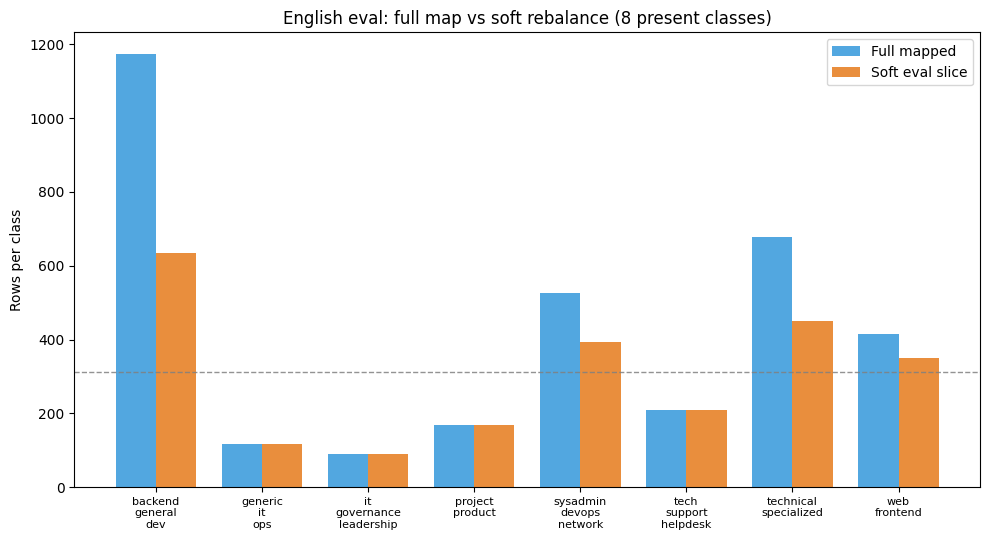

Saved /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/english_balanced_eval/fig_class_counts_before_after.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(EIGHT_CLASS_ORDER))
w = 0.38
ax.bar(x - w / 2, compare["rows_before_full_map"], width=w, label="Full mapped", color="#3498db", alpha=0.85)
ax.bar(
    x + w / 2,
    compare["rows_after_soft_rebalance"],
    width=w,
    label="Soft eval slice",
    color="#e67e22",
    alpha=0.88,
)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in EIGHT_CLASS_ORDER], fontsize=8)
ax.set_ylabel("Rows per class")
ax.set_title("English eval: full map vs soft rebalance (8 present classes)")
ax.axhline(median_deduped, color="gray", linestyle="--", linewidth=1, alpha=0.85)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_class_counts_before_after.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", FIG_DIR / "fig_class_counts_before_after.png")


## Key takeaways

- **Relationship to 32.** Notebook **32** defines the **full** English benchmark (cleaning, mapping, coverage, splits). Notebook **54** only **reads** `data/processed/english_dataset_v1/` and writes a **separate** eval CSV—it does not replace or redefine the benchmark.
- **What 54 changes.** The **soft** slice trims **only** classes that are **above** the **deduped** per-class **median** (`median + SOFT_PULL × excess`); smaller classes stay complete after dedupe. Sampling is **stratified** by `source` × `has_city_mention`, documented in `balancing_summary.json` and `class_counts_before_after.csv`.
- **When to use this slice.** Prefer **`english_balanced_8class_eval.csv`** when **extreme imbalance** in the full map would dominate metrics or comparisons, while you still want an **honest** (not perfectly balanced) English distribution. For **official** row counts, coverage, and splits, use **32** outputs and **`32_english_benchmark_manifest.json`**.
- **Eight classes.** English currently has **eight** present ontology classes (`sales_account` absent); neither 32 nor 54 invents that class.


